<h1>FFNN From Scratch</h1>
<h2>Depth Width Analysis</h2>

<h3>Configure Root</h3>

In [1]:
import sys
from pathlib import Path as path

root = path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

<h3>Import Library</h3>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.model.layers import FFNN
from src.model.activations import Activation
from src.model.loss import Loss
from src.model.optimizer import GradientDescent
from src.model.initializer import Initializer
from src.utils.data_loader import DataLoader
from src.utils.visualization import Visualizer

<h3>Importing Data</h3>

In [3]:
loader = DataLoader('../data/datasetml_2026.csv')
loader.load()
loader.eda()
loader.split(train_ratio=0.8, random_seed=42)
loader.preprocess()
loader.split_val(val_size=0.2, random_state=42)

X_train, y_train = loader.get_train()
X_val, y_val   = loader.get_val()
X_test, y_test  = loader.get_test()

X_train = np.asarray(X_train,dtype=np.float64)
X_val = np.asarray(X_val,dtype=np.float64)
X_test = np.asarray(X_test,dtype=np.float64)
y_train = np.asarray(y_train,dtype=np.float64)
y_val = np.asarray(y_val,dtype=np.float64)
y_test = np.asarray(y_test,dtype=np.float64)

INPUT_DIM = X_train.shape[1]
print(f'Input dim: {INPUT_DIM}')
print(f'Train: {X_train.shape}')
print(f'Val: {X_val.shape}')
print(f'Test: {X_test.shape}')

[DataLoader] Berhasil memuat 10000 baris dan 12 kolom dari '../data/datasetml_2026.csv'

[DataLoader] Kolom: ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score', 'placement_status']

                          Head Dataset                           


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed



                      Datatypes Dataset===                       
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  str    
 3   country                   10000 non-null  str    
 4   university_ranking_band   10000 non-null  str    
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  str    
 9   industry                  10000 non-null  str    
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  str    
dtypes: float64(4), int64(2), str(6)
memory usage: 937.6 KB


None


                     Informasi Missing Data                      


...

np.int64(0)


                  Informasi Outlier (Metode IQR                  
cgpa: 83 outliers
backlogs: 29 outliers
internship_count: 662 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 36 outliers

                   Informasi Distribusi Target                   


placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64

placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64

[DataLoader] Data di-split: 8000 Train, 2000 Test



               Informasi Outlier Setelah Clipping                
cgpa: 0 outliers
backlogs: 0 outliers
internship_count: 0 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 0 outliers
[DataLoader] Preprocessing selesai.
[DataLoader] X_train : (6400, 21) | y_train : (6400,)
[DataLoader] X_val   : (1600, 21)   | y_val   : (1600,)
Input dim: 21
Train: (6400, 21)
Val: (1600, 21)
Test: (2000, 21)


<h3>Initialize Model (Width)</h3>

In [4]:
# width kecil
model_w1 = FFNN(
    input_dim=INPUT_DIM,
    hidden_dim=[32, 32, 32],
    output_dim=1,
    hidden_activation='relu',
    output_activation='sigmoid',
    loss_name='bce',
    init_method='he',
    seed=42
)

# width sedang
model_w2 = FFNN(
    input_dim=INPUT_DIM,
    hidden_dim=[128, 128, 128],
    output_dim=1,
    hidden_activation='relu',
    output_activation='sigmoid',
    loss_name='bce',
    init_method='he',
    seed=42
)

# width besar
model_w3 = FFNN(
    input_dim=INPUT_DIM,
    hidden_dim=[512, 512, 512],
    output_dim=1,
    hidden_activation='relu',
    output_activation='sigmoid',
    loss_name='bce',
    init_method='he',
    seed=42
)

[FFNN] architecture initialized with: 21 -> 32 -> 32 -> 32 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: he, seed=42
[FFNN] architecture initialized with: 21 -> 128 -> 128 -> 128 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: he, seed=42
[FFNN] architecture initialized with: 21 -> 512 -> 512 -> 512 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: he, seed=42


<h3>Train Models (Width)</h3>

In [5]:
optimizer_w1 = GradientDescent(lr=0.01)
optimizer_w2 = GradientDescent(lr=0.01)
optimizer_w3 = GradientDescent(lr=0.01)

viz = Visualizer()
epochs = 100
batch_size = 32

models_width = [
    ('Width-32',  model_w1, optimizer_w1),
    ('Width-128', model_w2, optimizer_w2),
    ('Width-512', model_w3, optimizer_w3),
]

# training loop
for name, model, optimizer in models_width:
    viz.print_section_term(f"Training {name}")
    for epoch in range(1, epochs + 1):
        metrics = model.train_epoch(
            X_train, y_train,
            optimizer=optimizer,
            batch_size=batch_size,
            x_val=X_val,
            y_val=y_val,
        )
        print(f"Epoch {epoch:03d}/{epochs} | "
              f"Train loss: {metrics['train_loss']:.4f}, acc: {metrics['train_acc']:.4f} | "
              f"Val loss: {metrics['val_loss']:.4f}, acc: {metrics['val_acc']:.4f}")


                        Training Width-32                        
Epoch 001/100 | Train loss: 0.6659, acc: 0.6445 | Val loss: 0.6147, acc: 0.6400
Epoch 002/100 | Train loss: 0.5941, acc: 0.7089 | Val loss: 0.5596, acc: 0.7144
Epoch 003/100 | Train loss: 0.5537, acc: 0.7255 | Val loss: 0.5269, acc: 0.7481
Epoch 004/100 | Train loss: 0.5324, acc: 0.7402 | Val loss: 0.5081, acc: 0.7625
Epoch 005/100 | Train loss: 0.5211, acc: 0.7420 | Val loss: 0.4989, acc: 0.7631
Epoch 006/100 | Train loss: 0.5137, acc: 0.7439 | Val loss: 0.4938, acc: 0.7638
Epoch 007/100 | Train loss: 0.5089, acc: 0.7498 | Val loss: 0.4928, acc: 0.7612
Epoch 008/100 | Train loss: 0.5053, acc: 0.7512 | Val loss: 0.4872, acc: 0.7650
Epoch 009/100 | Train loss: 0.5022, acc: 0.7523 | Val loss: 0.4851, acc: 0.7612
Epoch 010/100 | Train loss: 0.4998, acc: 0.7547 | Val loss: 0.4839, acc: 0.7612
Epoch 011/100 | Train loss: 0.4979, acc: 0.7566 | Val loss: 0.4839, acc: 0.7656
Epoch 012/100 | Train loss: 0.4963, acc: 0.7570 | Val

<h3>Plot Visualization</h3>

[Visualizer] saved in ../results/width_comparison_loss.png


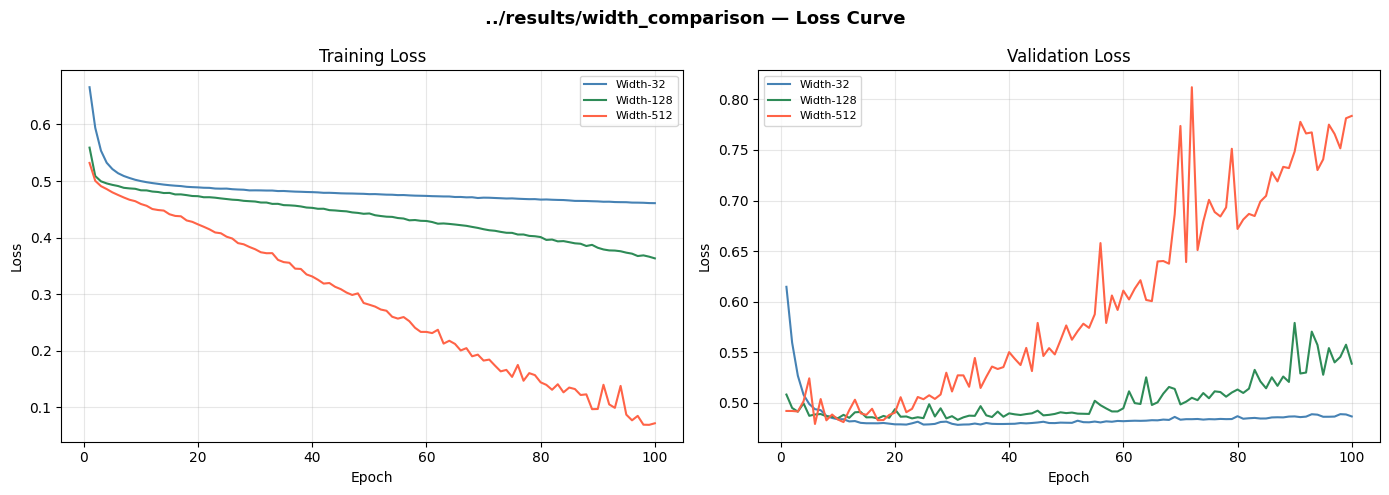


                        Width Comparison                         
Width-32: accuracy = 0.7345
Width-128: accuracy = 0.7165
Width-512: accuracy = 0.7015


In [6]:
results_width = {
    'Width-32'  : {'history': model_w1.get_training_history(), 'model': model_w1, 'color': 'steelblue'},
    'Width-128' : {'history': model_w2.get_training_history(), 'model': model_w2, 'color': 'seagreen'},
    'Width-512' : {'history': model_w3.get_training_history(), 'model': model_w3, 'color': 'tomato'},
}

viz.plot_comparison(
    results=results_width,
    mode='loss',
    save_prefix='../results/width_comparison'
)

viz.print_section_term("Width Comparison")
for name, r in results_width.items():
    y_pred = r['model'].predict(X_test)
    acc = (y_pred == y_test).mean()
    print(f"{name}: accuracy = {acc:.4f}")

<h3>Initialize Models (Depth)</h3>

In [7]:
# shallow: 2 hidden layer
model_d1 = FFNN(
    input_dim=INPUT_DIM,
    hidden_dim=[128, 128],
    output_dim=1,
    hidden_activation='relu',
    output_activation='sigmoid',
    loss_name='bce',
    init_method='he',
    seed=42
)

# medium: 4 hidden layer
model_d2 = FFNN(
    input_dim=INPUT_DIM,
    hidden_dim=[128, 128, 128, 128],
    output_dim=1,
    hidden_activation='relu',
    output_activation='sigmoid',
    loss_name='bce',
    init_method='he',
    seed=42
)

# deep: 6 hidden layer
model_d3 = FFNN(
    input_dim=INPUT_DIM,
    hidden_dim=[128, 128, 128, 128, 128, 128],
    output_dim=1,
    hidden_activation='relu',
    output_activation='sigmoid',
    loss_name='bce',
    init_method='he',
    seed=42
)

[FFNN] architecture initialized with: 21 -> 128 -> 128 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: he, seed=42
[FFNN] architecture initialized with: 21 -> 128 -> 128 -> 128 -> 128 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: he, seed=42
[FFNN] architecture initialized with: 21 -> 128 -> 128 -> 128 -> 128 -> 128 -> 128 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: he, seed=42


<h3>Train Models (Depth)</h3>

In [8]:
optimizer_d1 = GradientDescent(lr=0.01)
optimizer_d2 = GradientDescent(lr=0.01)
optimizer_d3 = GradientDescent(lr=0.01)

models_depth = [
    ('Depth-2', model_d1, optimizer_d1),
    ('Depth-4', model_d2, optimizer_d2),
    ('Depth-6', model_d3, optimizer_d3),
]

for name, model, optimizer in models_depth:
    viz.print_section_term(f"Training {name}")
    for epoch in range(1, epochs + 1):
        metrics = model.train_epoch(
            X_train, y_train,
            optimizer=optimizer,
            batch_size=batch_size,
            x_val=X_val,
            y_val=y_val,
        )
        print(f"Epoch {epoch:03d}/{epochs} | "
              f"Train loss: {metrics['train_loss']:.4f}, acc: {metrics['train_acc']:.4f} | "
              f"Val loss: {metrics['val_loss']:.4f}, acc: {metrics['val_acc']:.4f}")


                        Training Depth-2                         
Epoch 001/100 | Train loss: 0.5592, acc: 0.7512 | Val loss: 0.5035, acc: 0.7656
Epoch 002/100 | Train loss: 0.5083, acc: 0.7542 | Val loss: 0.4906, acc: 0.7569
Epoch 003/100 | Train loss: 0.5009, acc: 0.7527 | Val loss: 0.4930, acc: 0.7606
Epoch 004/100 | Train loss: 0.4974, acc: 0.7598 | Val loss: 0.4860, acc: 0.7562
Epoch 005/100 | Train loss: 0.4948, acc: 0.7611 | Val loss: 0.4856, acc: 0.7562
Epoch 006/100 | Train loss: 0.4944, acc: 0.7597 | Val loss: 0.4849, acc: 0.7581
Epoch 007/100 | Train loss: 0.4931, acc: 0.7623 | Val loss: 0.4823, acc: 0.7631
Epoch 008/100 | Train loss: 0.4920, acc: 0.7608 | Val loss: 0.4831, acc: 0.7612
Epoch 009/100 | Train loss: 0.4906, acc: 0.7622 | Val loss: 0.4820, acc: 0.7594
Epoch 010/100 | Train loss: 0.4897, acc: 0.7636 | Val loss: 0.4811, acc: 0.7619
Epoch 011/100 | Train loss: 0.4883, acc: 0.7583 | Val loss: 0.4847, acc: 0.7606
Epoch 012/100 | Train loss: 0.4882, acc: 0.7630 | Val

<h3>Plot Visualization</h3>

[Visualizer] saved in ../results/depth_comparison_loss.png


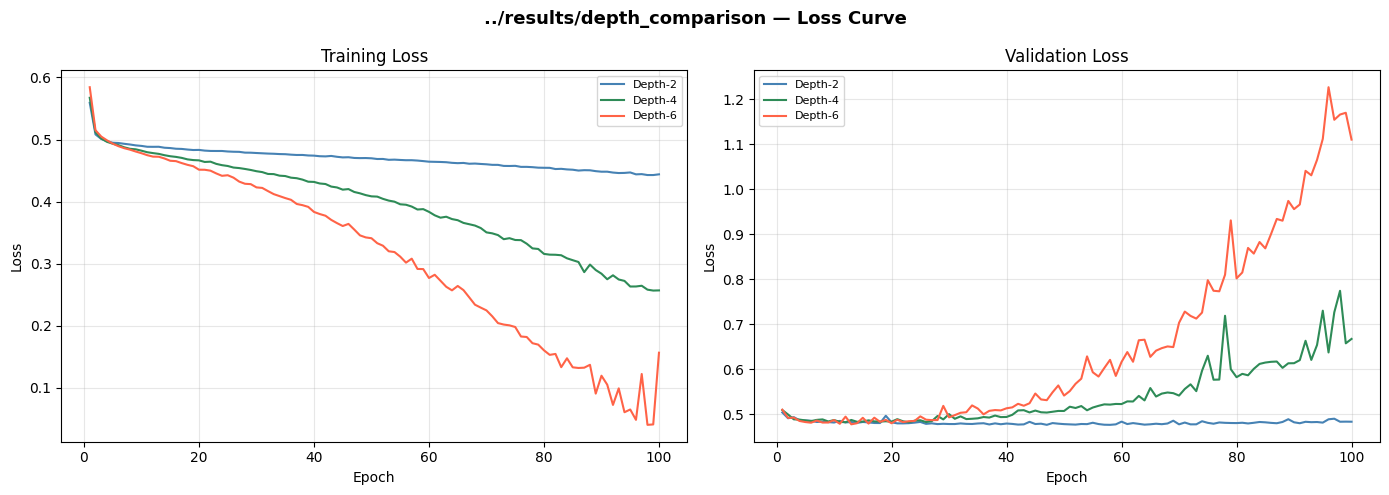


                        Depth Comparison                         
Depth-2: accuracy = 0.7245
Depth-4: accuracy = 0.6980
Depth-6: accuracy = 0.6885


In [9]:
results_depth = {
    'Depth-2' : {'history': model_d1.get_training_history(), 'model': model_d1, 'color': 'steelblue'},
    'Depth-4' : {'history': model_d2.get_training_history(), 'model': model_d2, 'color': 'seagreen'},
    'Depth-6' : {'history': model_d3.get_training_history(), 'model': model_d3, 'color': 'tomato'},
}

viz.plot_comparison(
    results=results_depth,
    mode='loss',
    save_prefix='../results/depth_comparison'
)

viz.print_section_term("Depth Comparison")
for name, r in results_depth.items():
    y_pred = r['model'].predict(X_test)
    acc = (y_pred == y_test).mean()
    print(f"{name}: accuracy = {acc:.4f}")